<a href="https://colab.research.google.com/github/Nilufar-Komil/Applications-of-the-Generalized-Stiefel-Manifold-in-NN/blob/Train-L%2Bq%2Bfrozen-in-5/trivial_%2B_train_Q%2BL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Beginning***

Problem is image classification. Number of classes are 10: cat, dog, bird and etc.Images' resolution are 32*32.
Do not forget to change the run time to the GPU.




#***Imports***
Lets start by getting all our imports, keep in mind that PyTorch is not automatically detects and trains on GPU, you have to tell it to use cuda. In case you want to train on Mac Silicon replace cuda with mps.

In [19]:
import torch.nn as nn
import random
import torch # Main PyTorch Library
import torchvision # Pytorch library for image analysis
from torchvision import transforms  # Transform function used to modify and preprocess all the images
from torch import nn # Used for creating the layers and loss function
from torch.optim import Adam # Adam Optimizer
from torch.utils.data import Dataset, DataLoader # Dataset class and DataLoader for creating the objects
from sklearn.preprocessing import LabelEncoder # Label Encoder to encode the classes from strings to numbers
import matplotlib.pyplot as plt # Used for visualizing the images and plotting the training progress
from PIL import Image # Used to read the images from the directory
import pandas as pd # Used to read/create dataframes (csv) and process tabular data
import numpy as np # preprocessing and numerical/mathematical operations
import os # Used to read the images path from the directory
from torch.utils.data import random_split #Used to split data sets
device = "cuda" if torch.cuda.is_available() else "cpu" # detect the GPU if any, if not use CPU, change cuda to mps if you have a mac
print("Device available: ", device)

Device available:  cpu


#***Downoad Data Set***

In Colab, PyTorch can download it for me for CIFAR 10 data set.

In [20]:
import torchvision.transforms as transforms
transform = transforms.ToTensor()   # turn image into tensor

# Normalize all images: shift pixel values within -1 and 1
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

full_train_dataset = torchvision.datasets.CIFAR10(
    root="./data",                  # save/load dataset in this folder
    train=True,                     # use training data
    download=True,                  # download if needed
    transform=transform             # apply transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",                  # save/load dataset in this folder
    train=False,                    # use test data
    download=True,                  # download if needed
    transform=transform             # apply transform
)

# print size of each data sets
print("Train size:", len(full_train_dataset))
print("Test size:", len(test_dataset))


Train size: 50000
Test size: 10000


#***Train / validation / test split***

In CIFAR 10 dataset training and test datasets are already separated. We split only training dataset to validation and training parts.




In [21]:
# split full training data set to training and validation parts
train_size = int(0.8 * len(full_train_dataset))   # 80% for training
val_size = len(full_train_dataset) - train_size   # 20% for validation

train_dataset, val_dataset = random_split(
    full_train_dataset,             # dataset to split
    [train_size, val_size],         # sizes of split parts
    generator=torch.Generator().manual_seed(42)   # makes the train/validation split stay the same every time
)

# printing each data sets sizes
print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))



Train size: 40000
Val size: 10000
Test size: 10000



For standard CIFAR-10, we usually do not need a custom dataset class.
Because this already does the dataset job for us: `torchvision.datasets.CIFAR10(...)`

It already knows how to:
* load CIFAR-10
* return image and label
* apply transforms
* work with DataLoader

#***Define Hyperparameters***
We define hyperparameters: batch size, learning rate, and epoch.

In [22]:
# Defining hyperparameters
LR = 1e-4
batch_size = 64
EPOCHS = 25

# Fixing randomness in each run: used in PyTorch, Numpy, Python, and GPU random operations:
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

#***DataLoaders***



In [23]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)   # shuffled train batches
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)      # validation batches
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)    # test batches


In [34]:

import torch
import torch.nn as nn
import torch.nn.functional as F


class ProductGStiefelConv2d(nn.Module):
    """
    Convolution layer with:
      - fast inner variables: X, Z   (updated every batch)
      - slow outer geometry: Q1, ell (updated once per epoch or every few epochs)

    Geometry:
        B = Q1 diag(exp(ell)) Q1^T

    Conventions:
      - flattened filter matrix W is interpreted mathematically as shape (n, p)
        where
            n = in_channels * kernel_size * kernel_size
            p = out_channels

      - Stiefel variables are stored in optimizer-friendly shape:
            Q1 parameter shape = (rank, n)
            X  parameter shape = (rank, p)

        so your current Stiefel optimizer sees rows <= cols.

      - Euclidean variable:
            Z parameter shape = (n-rank, p)
    """

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int,
        diffeo,
        stride: int = 1,
        padding: int = 0,
        bias: bool = True,
        metric_lr_scale: float = 1.0,
    ):
        super().__init__()


        # basic layer information
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding

        # layer-specific generalized-Stiefel diffeomorphism object
        self.diffeo = diffeo

        # flattened ambient dimension n and output dimension p
        self.n = in_channels * kernel_size * kernel_size
        self.p = out_channels

        # fixed rank of the metric
        self.rank = diffeo.rank

        # optional bookkeeping scalar for optimizer grouping
        self.metric_lr_scale = metric_lr_scale


        # initialize slow outer metric variables:
        B0 = diffeo.B.detach().clone()
        device = B0.device
        dtype = B0.dtype

        # symmetric cleanup
        B0 = 0.5 * (B0 + B0.t())

        # eigendecomposition of initial metric
        evals, evecs = torch.linalg.eigh(B0)

        # take the largest 'rank' eigenpairs
        idx = torch.argsort(evals, descending=True)[:self.rank]
        evals_r = torch.clamp(evals[idx], min=1e-8)
        Q1_0 = evecs[:, idx]  # shape (n, rank)

        # store Q1 as (rank, n) for Stiefel optimizer
        self.Q1 = nn.Parameter(Q1_0.t().contiguous())

        # store ell so that Lambda = diag(exp(ell))
        self.ell = nn.Parameter(torch.log(evals_r.contiguous()))

        # initialize fast inner product coordinates
        X_std, Z_std = diffeo.random_product_point(self.p)


        self.X = nn.Parameter(X_std.t().contiguous())   # shape (p, rank)
        # Z_std keeps mathematical / Euclidean shape (n-rank, p)
        self.Z = nn.Parameter(Z_std.contiguous())


        # optional bias
        if bias:
            self.bias = nn.Parameter(
                torch.zeros(out_channels, device=device, dtype=dtype)
            )
        else:
            self.register_parameter("bias", None)

        # initialize diffeo metric from current Q1, ell
        self.update_diffeo_metric_()

    # ------------------------------------------------------------------
    # geometry helpers
    # ------------------------------------------------------------------
    def get_Q1_matrix(self) -> torch.Tensor:
        """
        Return Q1 with mathematical shape (n, rank).
        Stored parameter has shape (rank, n).
        """
        return self.Q1.t()

    def get_Lambda_matrix(self) -> torch.Tensor:
        """
        Return Lambda = diag(exp(ell)) with shape (rank, rank).
        """
        Lambda = torch.diag(torch.exp(self.ell))
        return Lambda

    @torch.no_grad()

    def get_metric_B(self) -> torch.Tensor:
        """
        Build B = Q1 diag(exp(ell)) Q1^T, shape (n, n).
        """
        Q1 = self.get_Q1_matrix()          # (n, rank)
        Lambda = self.get_Lambda_matrix()  # (rank, rank)
        B = Q1 @ Lambda @ Q1.t()           # (n, n)
        B = 0.5 * (B + B.t())              # numerical cleanup
        return B

    @torch.no_grad()
    def update_diffeo_metric_(self) -> None:
        """
        Push the current learned metric B into the diffeomorphism object.
        Call this at the beginning of each epoch (or each outer update).
        """
        B = self.get_metric_B().detach()
        self.diffeo.set_B(B)

    @torch.no_grad()
    def derive_Q2(self) -> torch.Tensor:
        """
        Compute an orthonormal complement Q2 to Q1.
        Returns shape (n, n-rank).

        This is derived, never optimized directly.
        """
        Q1 = self.get_Q1_matrix()  # (n, rank)

        if self.rank == self.n:
            return torch.empty(self.n, 0, device=Q1.device, dtype=Q1.dtype)

        # complete Q1 to a full orthonormal basis using QR
        I = torch.eye(self.n, device=Q1.device, dtype=Q1.dtype)
        M = torch.cat([Q1, I], dim=1)
        Q_full, _ = torch.linalg.qr(M, mode="complete") #used qr
        Q2 = Q_full[:, self.rank:self.n]
        return Q2

    @torch.no_grad()
    def refresh_product_coordinates_(self) -> None:
        """
        Optional coordinate refresh after an outer metric update.

        Procedure:
          1) reconstruct the actual weight W under the current coordinates
          2) sync diffeo.B to the new metric
          3) map W back to new product coordinates through phi() if available

        Assumes:
            X_std_new, Z_std_new = diffeo.phi(W_np)
        where W_np has shape (n, p).
        """
        # reconstruct current actual weight under current coordinates
        X_std_old = self.X.t().contiguous()   # (rank, p)
        Z_std_old = self.Z                # (n-rank, p)
        W_np = self.diffeo.phi_inverse(X_std_old, Z_std_old)  # (n, p)

        # sync metric first
        self.update_diffeo_metric_()

        # refresh coordinates only if phi exists
        if hasattr(self.diffeo, "phi") and callable(self.diffeo.phi):
            X_std_new, Z_std_new = self.diffeo.phi(W_np)
            self.X.data.copy_(X_std_new.t().contiguous())
            self.Z.data.copy_(Z_std_new.contiguous())

    # ------------------------------------------------------------------
    # forward reconstruction
    # ------------------------------------------------------------------
    def reconstruct_weight(self) -> torch.Tensor:
        """
        Reconstruct constrained convolution weight from current fast variables
        under the current metric stored in self.diffeo.B.
        """
        # X and Z are already in the mathematical shapes expected by phi_inverse

        X_std = self.X.t()
        Z_std = self.Z   # (n-rank, p)

        # reconstruct flattened generalized-Stiefel weight, shape (n, p)
        W_flat_np = self.diffeo.phi_inverse(X_std, Z_std)

        # convert to convolution weight layout: (p, n)
        W_flat_pn = W_flat_np.t()

        # reshape to 4D conv kernel
        W = W_flat_pn.view(
            self.out_channels,
            self.in_channels,
            self.kernel_size,
            self.kernel_size,
        )
        return W

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        W = self.reconstruct_weight()
        return F.conv2d(
            x,
            W,
            bias=self.bias,
            stride=self.stride,
            padding=self.padding,
        )


class CIFAR10_CNN_Product(nn.Module):
    def __init__(self, phi2, phi3, phi4):
        super().__init__()

        # unconstrained first layer
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3,
            padding=1,
        )
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)

        # constrained layers with fast (X,Z) and slow (Q1,ell)
        self.conv2 = ProductGStiefelConv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1,
            diffeo=phi2,
        )
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = ProductGStiefelConv2d(
            in_channels=64,
            out_channels=128,
            kernel_size=3,
            padding=1,
            diffeo=phi3,
        )
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2, 2)

        self.conv4 = ProductGStiefelConv2d(
            in_channels=128,
            out_channels=256,
            kernel_size=3,
            padding=1,
            diffeo=phi4,
        )
        self.relu4 = nn.ReLU()
        self.pool4 = nn.MaxPool2d(2, 2)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(256 * 2 * 2, 256)
        self.relu5 = nn.ReLU()
        self.drop1 = nn.Dropout(0.2)

        self.fc2 = nn.Linear(256, 128)
        self.relu6 = nn.ReLU()
        self.drop2 = nn.Dropout(0.5)

        self.fc3 = nn.Linear(128, 10)

    # --------------------------------------------------------------
    # helpers for outer geometry updates
    # --------------------------------------------------------------
    def constrained_layers(self):
        return [self.conv2, self.conv3, self.conv4]

    @torch.no_grad()
    def update_all_diffeo_metrics_(self):
        """
        Call this at the beginning of each epoch after outer metric updates.
        """
        for layer in self.constrained_layers():
            layer.update_diffeo_metric_()

    @torch.no_grad()
    def refresh_all_product_coordinates_(self):
        """
        Optional: call this after outer metric updates if you want to
        re-express X,Z under the new geometry.
        """
        for layer in self.constrained_layers():
            layer.refresh_product_coordinates_()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        x = self.pool4(self.relu4(self.conv4(x)))

        x = self.flatten(x)
        x = self.relu5(self.fc1(x))
        x = self.drop1(x)

        x = self.relu6(self.fc2(x))
        x = self.drop2(x)

        x = self.fc3(x)
        return x

#***Loss Function***

As our probem is classification problem, we use Cross entropy as loss function.

In [25]:
# Define loss function
criterion = nn.CrossEntropyLoss() # Cross Entropy Loss

#***Define matrix B manually***

We should fix matrix $B$ for defining generalized Stiefel manifold.As we do optimization layerwise, we use different metrics ($B$ matrices) for each layer. Requirement for well-defined problem:
* $B_i$ is positive semidefinitive for all $i = 1, 2, 3, 4.$
* $rank(B_1) \geq 32$   # impossible because B1 is only 27x27
* $rank(B_2) \geq 64$
* $rank(B_3) \geq 128$
* $rank(B_4) \geq 256$

In [26]:

# conv1 is not feasible in current row-form setup
B1 = None

dtype = torch.float32

# conv2: size 288 x 288
d2 = torch.linspace(0.5, 3.0, 288, device=device, dtype=dtype)
d2[:40] = 0.0
B2 = torch.diag(d2)

# conv3: size 576 x 576
d3 = torch.linspace(0.2, 2.5, 576, device=device, dtype=dtype)
d3[:80] = 0.0
B3 = torch.diag(d3)

# conv4: size 1152 x 1152
d4 = torch.linspace(0.1, 2.0, 1152, device=device, dtype=dtype)
d4[:120] = 0.0
B4 = torch.diag(d4)

#Saving all weights as a dictionaty
layer_B_map = {
    "conv2.weight": B2,
    "conv3.weight": B3,
    "conv4.weight": B4,
}

#***Diffeomorphism***

Define the map
$$
\Phi : \mathrm{St}_B(p,n)
\to
\mathrm{St}(p,r) \times \mathbb{R}^{(n-r)\times p}
$$
by
$$
\boxed{
\Phi(X)
=
\left(
\Lambda^{1/2} X_1,\; X_2
\right)
}
\quad \text{where }
\begin{pmatrix}
X_1 \\
X_2
\end{pmatrix}
= Q^\top X.
$$

---

In [27]:

# import future annotations so type hints can reference the class itself safely
from __future__ import annotations

# import torch for tensor and linear algebra operations
import torch


# ------------------------------------------------------------
# Helper function:
# return the symmetric part of a square matrix
# ------------------------------------------------------------
def sym(A: torch.Tensor) -> torch.Tensor:
    return 0.5 * (A + A.T)


# ------------------------------------------------------------
# Diffeomorphism between generalized Stiefel St_B and a product
# manifold consisting of:
#   - a standard Stiefel part X in St(rank, p)
#   - a Euclidean part Z in R^{(n-rank) x p}
#
# If B = Q diag(Lambda, 0) Q^T with rank r, and W is written as
#
#   Q^T W = [W1]
#           [W2]
#
# then define
#
#   X = Lambda^(1/2) W1
#   Z = W2
#
# and reconstruct by
#
#   W1 = Lambda^(-1/2) X
#   W  = Q1 W1 + Q2 Z
#
# For W in St_B, the Stiefel part satisfies X^T X = I.
# ------------------------------------------------------------
class GeneralizedStiefelDiffeomorphismTorch:
    def __init__(self, B: torch.Tensor, tol: float = 1e-10):
        # numerical tolerance used for rank decisions and checks
        self.tol = tol

        # initialize all decomposition-dependent fields
        self.set_B(B)

    # --------------------------------------------------------
    # Recompute the full eigendecomposition-based factorization
    # from a new metric matrix B.
    #
    # This MUST be called whenever B changes.
    # --------------------------------------------------------
    def set_B(self, B: torch.Tensor) -> None:
        # store the matrix B
        self.B = B

        # store device and dtype for creating compatible tensors later
        self.device = B.device
        self.dtype = B.dtype

        # check that B is square
        if B.ndim != 2 or B.shape[0] != B.shape[1]:
            raise ValueError("B must be a square matrix.")

        # store ambient dimension n
        self.n = B.shape[0]

        # enforce symmetry numerically to avoid tiny asymmetry problems
        Bsym = sym(B)

        # eigen-decomposition of symmetric B
        evals, Q = torch.linalg.eigh(Bsym)

        # sort eigenvalues from largest to smallest
        idx = torch.argsort(evals, descending=True)
        evals = evals[idx]
        Q = Q[:, idx]

        # Clamp eigenvalues to ensure non-negativity due to potential numerical precision issues
        evals = torch.clamp(evals, min=0.0)

        # numerical rank = number of eigenvalues greater than tolerance
        rank_tol = max(self.tol, 1e-6 * evals[0].item())
        rank = int((evals > rank_tol).sum().item())

        # store rank(B)
        self.rank = rank

        # store full eigenvector matrix
        self.Q = Q

        # store sorted eigenvalues
        self.evals = evals

        # split Q into image-space basis Q1 and null-space basis Q2
        self.Q1 = Q[:, :rank]
        self.Q2 = Q[:, rank:]

        # positive eigenvalues only
        if rank > 0:
            lam = evals[:rank]

            # diagonal matrix Lambda
            self.Lambda = torch.diag(lam)

            # diagonal square root Lambda^(1/2)
            self.Lambda_half = torch.diag(torch.sqrt(lam))

            # diagonal inverse square root Lambda^(-1/2)
            self.Lambda_half_inv = torch.diag(1.0 / torch.sqrt(lam))
        else:
            # if rank is zero, create empty matrices with correct shapes
            self.Lambda = torch.empty((0, 0), device=self.device, dtype=self.dtype)
            self.Lambda_half = torch.empty((0, 0), device=self.device, dtype=self.dtype)
            self.Lambda_half_inv = torch.empty((0, 0), device=self.device, dtype=self.dtype)

    # --------------------------------------------------------
    # Check whether W belongs to the generalized Stiefel manifold:
    #     W^T B W = I
    # Here W must have shape (n, p)
    # --------------------------------------------------------
    def in_generalized_stiefel(self, W: torch.Tensor) -> bool:
        # check ambient dimension
        if W.ndim != 2 or W.shape[0] != self.n:
            return False

        # number of columns p
        p = W.shape[1]

        # rank condition for generalized Stiefel feasibility
        if p > self.rank:
            return False

        # compute W^T B W
        gram = W.T @ self.B @ W

        # compare against identity
        I = torch.eye(p, device=W.device, dtype=W.dtype)

        # return whether the constraint is satisfied up to tolerance
        return torch.norm(gram - I) <= 1e2 * self.tol

    # --------------------------------------------------------
    # Map W in St_B to product coordinates (X, Z)
    #
    # Input:
    #   W : shape (n, p)
    #
    # Output:
    #   X : shape (rank, p)  with X^T X = I if W in St_B
    #   Z : shape (n-rank, p)
    # --------------------------------------------------------
    def phi(self, W: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        # check shape
        if W.ndim != 2 or W.shape[0] != self.n:
            raise ValueError(f"W must have shape ({self.n}, p).")

        p = W.shape[1]
        if p > self.rank:
            raise ValueError(
                f"Cannot map W with p={p} columns because rank(B)={self.rank}. "
                "Need p <= rank(B)."
            )

        # coordinates of W in the Q basis
        QtW = self.Q.T @ W

        # top block in the range of B
        W1 = QtW[:self.rank, :]

        # bottom block in the null-space of B
        W2 = QtW[self.rank:, :]

        # Stiefel part:
        # X = Lambda^(1/2) W1
        if self.rank > 0:
            X = self.Lambda_half @ W1
        else:
            X = torch.empty((0, p), device=W.device, dtype=W.dtype)

        # Euclidean part:
        Z = W2

        return X, Z

    # --------------------------------------------------------
    # Inverse map from product coordinates (X, Z) back to W
    #
    # Input:
    #   X : shape (rank, p)
    #   Z : shape (n-rank, p)
    #
    # Output:
    #   W : shape (n, p)
    # --------------------------------------------------------
    def phi_inverse(self, X: torch.Tensor, Z: torch.Tensor) -> torch.Tensor:
        # check dimensions of X
        if X.ndim != 2:
            raise ValueError("X must be a matrix of shape (rank, p).")

        # check dimensions of Z
        if Z.ndim != 2:
            raise ValueError("Z must be a matrix of shape (n-rank, p).")

        # both product blocks must have the same number of columns p
        if X.shape[1] != Z.shape[1]:
            raise ValueError("X and Z must have the same number of columns.")

        # X must have rank rows
        if X.shape[0] != self.rank:
            raise ValueError(f"X must have shape ({self.rank}, p).")

        # Z must have n-rank rows
        if Z.shape[0] != self.n - self.rank:
            raise ValueError(f"Z must have shape ({self.n - self.rank}, p).")

        # reconstruct W1 = Lambda^(-1/2) X
        if self.rank > 0:
            W1 = self.Lambda_half_inv @ X
        else:
            W1 = torch.empty((0, X.shape[1]), device=X.device, dtype=X.dtype)

        # reconstruct W = Q1 W1 + Q2 Z
        W = self.Q1 @ W1 + self.Q2 @ Z
        return W

    # --------------------------------------------------------
    # Create a valid random point in the product manifold
    #
    # Input:
    #   p : number of columns
    #
    # Output:
    #   X : shape (rank, p), satisfying X^T X = I
    #   Z : shape (n-rank, p), arbitrary Euclidean block
    #
    # Important geometric condition:
    #   for X^T X = I to be possible, we need p <= rank
    # --------------------------------------------------------
    def random_product_point(self, p: int) -> tuple[torch.Tensor, torch.Tensor]:
        # Stiefel part needs rank >= p
        if p > self.rank:
            raise ValueError(
                f"Cannot create a Stiefel point with p={p} columns when rank(B)={self.rank}. "
                "You need p <= rank(B)."
            )

        # build X in St(rank, p), meaning X has orthonormal columns
        A = torch.randn(self.rank, p, device=self.device, dtype=self.dtype)
        Qx, Rx = torch.linalg.qr(A, mode="reduced")

        # fix column signs so QR is deterministic up to sign
        d = torch.diagonal(Rx, 0)
        s = torch.sign(d)
        s[s == 0] = 1
        Qx = Qx * s.unsqueeze(0)

        # standard Stiefel variable
        X = Qx

        # Euclidean block starts from zeros
        Z = torch.zeros(self.n - self.rank, p, device=self.device, dtype=self.dtype)

        return X, Z

    # --------------------------------------------------------
    # Initialize product coordinates from an existing W in St_B
    # --------------------------------------------------------
    def init_from_W(self, W: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        if not self.in_generalized_stiefel(W):
            raise ValueError("Input W does not satisfy W^T B W = I up to tolerance.")
        return self.phi(W)

    # --------------------------------------------------------
    # Print a compact summary of the decomposition
    # --------------------------------------------------------
    def print_summary(self) -> None:
        print(f"n = {self.n}")
        print(f"rank(B) = {self.rank}")
        print("positive eigenvalues =", self.evals[:self.rank])
        print("Q1 shape =", tuple(self.Q1.shape))
        print("Q2 shape =", tuple(self.Q2.shape))

In [35]:
# ------------------------------------------------------------
# B2, B3, B4 must already be created in earlier cells.
#
# Their sizes should match the flattened convolution dimensions:
#
# conv2: n2 = 32 * 3 * 3
# conv3: n3 = 64 * 3 * 3
# conv4: n4 = 128 * 3 * 3
#
# and the corresponding numbers of filters are:
#
# conv2: p2 = 64
# conv3: p3 = 128
# conv4: p4 = 256
# ------------------------------------------------------------

# move each B matrix to the same device and dtype that the model will use
B2 = B2.to(device=device, dtype=torch.float32)
B3 = B3.to(device=device, dtype=torch.float32)
B4 = B4.to(device=device, dtype=torch.float32)


# ------------------------------------------------------------
# build one generalized-Stiefel diffeomorphism per constrained layer
# ------------------------------------------------------------
phi2 = GeneralizedStiefelDiffeomorphismTorch(B2, tol=1e-5)
phi3 = GeneralizedStiefelDiffeomorphismTorch(B3, tol=1e-5)
phi4 = GeneralizedStiefelDiffeomorphismTorch(B4, tol=1e-5)


# ------------------------------------------------------------
# define the number of filters p for each constrained layer
# ------------------------------------------------------------
p2 = 64
p3 = 128
p4 = 256


# ------------------------------------------------------------
# check the necessary condition for the product construction:
#
# for X in St(rank(B), p), we must have p <= rank(B)
# ------------------------------------------------------------
if phi2.rank < p2:
    raise ValueError(
        f"conv2 is not feasible: rank(B2)={phi2.rank} but p2={p2}. "
        "You need rank(B2) >= number of conv2 filters."
    )

if phi3.rank < p3:
    raise ValueError(
        f"conv3 is not feasible: rank(B3)={phi3.rank} but p3={p3}. "
        "You need rank(B3) >= number of conv3 filters."
    )

if phi4.rank < p4:
    raise ValueError(
        f"conv4 is not feasible: rank(B4)={phi4.rank} but p4={p4}. "
        "You need rank(B4) >= number of conv4 filters."
    )


# ------------------------------------------------------------
# print a short summary so you can verify the geometry
# ------------------------------------------------------------
print(f"conv2: n = {phi2.n}, rank(B2) = {phi2.rank}, p = {p2}")
print(f"conv3: n = {phi3.n}, rank(B3) = {phi3.rank}, p = {p3}")
print(f"conv4: n = {phi4.n}, rank(B4) = {phi4.rank}, p = {p4}")


# ------------------------------------------------------------
# create the CNN model
# ------------------------------------------------------------
model = CIFAR10_CNN_Product(phi2, phi3, phi4).to(device)

# after moving model to device, rebuild each diffeo cache from the
# current slow variables Q1 and ell stored inside the layer
#
# IMPORTANT:
#   B is not optimized directly.
#   It is derived from Q1 and ell.
# ------------------------------------------------------------
model.update_all_diffeo_metrics_()

print(model)


# ------------------------------------------------------------
# optional sanity checks:
# inspect the shapes of the trainable variables
# ------------------------------------------------------------
print("conv2.Q1 shape =", tuple(model.conv2.Q1.shape))   # (rank, n)
print("conv2.ell shape =", tuple(model.conv2.ell.shape)) # (rank,)
print("conv2.X shape  =", tuple(model.conv2.X.shape))    # (rank, p)
print("conv2.Z shape  =", tuple(model.conv2.Z.shape))    # (n-rank, p))

print("conv3.Q1 shape =", tuple(model.conv3.Q1.shape))
print("conv3.ell shape =", tuple(model.conv3.ell.shape))
print("conv3.X shape  =", tuple(model.conv3.X.shape))
print("conv3.Z shape  =", tuple(model.conv3.Z.shape))

print("conv4.Q1 shape =", tuple(model.conv4.Q1.shape))
print("conv4.ell shape =", tuple(model.conv4.ell.shape))
print("conv4.X shape  =", tuple(model.conv4.X.shape))
print("conv4.Z shape  =", tuple(model.conv4.Z.shape))


# ------------------------------------------------------------
# optional reconstruction check:
# rebuild one constrained weight and inspect its shape
# ------------------------------------------------------------
W2 = model.conv2.reconstruct_weight()
W3 = model.conv3.reconstruct_weight()
W4 = model.conv4.reconstruct_weight()

print("reconstructed conv2 weight shape =", tuple(W2.shape))
print("reconstructed conv3 weight shape =", tuple(W3.shape))
print("reconstructed conv4 weight shape =", tuple(W4.shape))


# ------------------------------------------------------------
# optional metric check:
# verify that each current B is derived from Q1, ell
# and that diffeo caches are synchronized
# ------------------------------------------------------------
B2_current = model.conv2.get_metric_B()
B3_current = model.conv3.get_metric_B()
B4_current = model.conv4.get_metric_B()

print("current derived B2 shape =", tuple(B2_current.shape))
print("current derived B3 shape =", tuple(B3_current.shape))
print("current derived B4 shape =", tuple(B4_current.shape))

print("current derived rank conv2 =", model.conv2.rank)
print("current derived rank conv3 =", model.conv3.rank)
print("current derived rank conv4 =", model.conv4.rank)

conv2: n = 288, rank(B2) = 248, p = 64
conv3: n = 576, rank(B3) = 496, p = 128
conv4: n = 1152, rank(B4) = 1032, p = 256
CIFAR10_CNN_Product(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): ProductGStiefelConv2d()
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): ProductGStiefelConv2d()
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): ProductGStiefelConv2d()
  (relu4): ReLU()
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=1024, out_features=256, bias=True)
  (relu5): ReLU()
  (drop1): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (relu6): ReLU()
  (drop2): Dr

#***Optimization Method***
We restrict weight parameters to Generalized Stiefel manifold and update this manifold first few epoch and then we fix "learned metric" then do optimization. We do not apply these method to all parameters so first we split paramaters two groups: `stifel_params` and `normal_params.`

In [29]:
!pip install nested_dict

In [36]:
import torch
from torch.optim import Optimizer

def sym(A: torch.Tensor) -> torch.Tensor:
    return 0.5 * (A + A.T)

# fast inner Stiefel variables: X
LR_X = 0.005

# slow outer Stiefel variables: Q1
LR_Q1 = 0.0001

# fast inner Euclidean variables: Z
LR_Z = 0.01

# slow outer Euclidean variables: ell
LR_ELL = 0.0005

# ordinary unconstrained network parameters
LR_OTHER = 0.01

# momentum coefficient for SGD-style optimizers
MOMENTUM = 0.9

# weight decay for ordinary Euclidean parameters
WEIGHT_DECAY = 1e-4


# ------------------------------------------------------------
# collect fast inner Stiefel variables X
# these are updated every batch
# ------------------------------------------------------------
x_stiefel_params = [
    model.conv2.X,
    model.conv3.X,
    model.conv4.X,
]


# ------------------------------------------------------------
# collect slow outer Stiefel variables Q1
# these are updated once per epoch or every few epochs
# ------------------------------------------------------------
q1_stiefel_params = [
    model.conv2.Q1,
    model.conv3.Q1,
    model.conv4.Q1,
]


# ------------------------------------------------------------
# collect fast inner Euclidean variables Z
# these are updated every batch
# ------------------------------------------------------------
z_euclid_params = [
    model.conv2.Z,
    model.conv3.Z,
    model.conv4.Z,
]


# ------------------------------------------------------------
# collect slow outer Euclidean variables ell
# these are updated once per epoch or every few epochs
# ------------------------------------------------------------
ell_euclid_params = [
    model.conv2.ell,
    model.conv3.ell,
    model.conv4.ell,
]


# ------------------------------------------------------------
# collect all ordinary unconstrained network parameters
#
# IMPORTANT:
# exclude:
#   - X
#   - Q1
#   - Z
#   - ell
# because those are handled explicitly above
# ------------------------------------------------------------
special_param_ids = {
    id(p)
    for p in (
        x_stiefel_params
        + q1_stiefel_params
        + z_euclid_params
        + ell_euclid_params
    )
}

other_params = [
    p for p in model.parameters()
    if id(p) not in special_param_ids
]


# ------------------------------------------------------------
# print parameter counts for sanity checking
# ------------------------------------------------------------
print("number of X Stiefel tensors   =", len(x_stiefel_params))
print("number of Q1 Stiefel tensors  =", len(q1_stiefel_params))
print("number of Z Euclidean tensors =", len(z_euclid_params))
print("number of ell tensors         =", len(ell_euclid_params))
print("number of other tensors       =", len(other_params))

for i, p in enumerate(x_stiefel_params, start=2):
    print(f"conv{i}.X shape   = {tuple(p.shape)}")

for i, p in enumerate(q1_stiefel_params, start=2):
    print(f"conv{i}.Q1 shape  = {tuple(p.shape)}")

for i, p in enumerate(z_euclid_params, start=2):
    print(f"conv{i}.Z shape   = {tuple(p.shape)}")

for i, p in enumerate(ell_euclid_params, start=2):
    print(f"conv{i}.ell shape = {tuple(p.shape)}")

from torch.optim.sgd import SGD
from stiefel_optimizer_modify import SGDG
# ------------------------------------------------------------
# optimizer for fast inner Stiefel variables X
# updated every batch
# ------------------------------------------------------------
x_stiefel_optimizer = SGDG(
    [
        {
            "params": x_stiefel_params,
            "lr": LR_X,
            "momentum": MOMENTUM,
            "stiefel": True,
            "weight_decay": 0.0,
        }
    ]
)

q1_stiefel_optimizer = SGDG(
    [
        {
            "params": q1_stiefel_params,
            "lr": LR_Q1,
            "momentum": MOMENTUM,
            "stiefel": True,
            "weight_decay": 0.0,
        }
    ]
)


# ------------------------------------------------------------
# optimizer for fast inner Euclidean variables Z
# updated every batch
# ------------------------------------------------------------
z_euclid_optimizer = torch.optim.SGD(
    z_euclid_params,
    lr=LR_Z,
    momentum=MOMENTUM,
    weight_decay=0.0,
)


# optimizer for slow outer Euclidean variables ell
# updated once per epoch or every few epochs
# Adam is usually a good stable choice here
ell_euclid_optimizer = torch.optim.Adam(
    ell_euclid_params,
    lr=LR_ELL,
    weight_decay=0.0,
)



# optimizer for ordinary unconstrained network parameters
# updated every batch
other_optimizer = torch.optim.SGD(
    other_params,
    lr=LR_OTHER,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,
)


# show all optimizers
print("x_stiefel_optimizer =", x_stiefel_optimizer)
print("q1_stiefel_optimizer =", q1_stiefel_optimizer)
print("z_euclid_optimizer =", z_euclid_optimizer)
print("ell_euclid_optimizer =", ell_euclid_optimizer)
print("other_optimizer =", other_optimizer)


number of X Stiefel tensors   = 3
number of Q1 Stiefel tensors  = 3
number of Z Euclidean tensors = 3
number of ell tensors         = 3
number of other tensors       = 11
conv2.X shape   = (64, 248)
conv3.X shape   = (128, 496)
conv4.X shape   = (256, 1032)
conv2.Q1 shape  = (248, 288)
conv3.Q1 shape  = (496, 576)
conv4.Q1 shape  = (1032, 1152)
conv2.Z shape   = (40, 64)
conv3.Z shape   = (80, 128)
conv4.Z shape   = (120, 256)
conv2.ell shape = (248,)
conv3.ell shape = (496,)
conv4.ell shape = (1032,)
x_stiefel_optimizer = SGDG (
Parameter Group 0
    dampening: 0
    grad_clip: None
    lr: 0.005
    momentum: 0.9
    nesterov: False
    omega: 0
    stiefel: True
    weight_decay: 0.0
)
q1_stiefel_optimizer = SGDG (
Parameter Group 0
    dampening: 0
    grad_clip: None
    lr: 0.0001
    momentum: 0.9
    nesterov: False
    omega: 0
    stiefel: True
    weight_decay: 0.0
)
z_euclid_optimizer = SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
   

#***Optimization on Product Manifold***

The clean way is to make one optimizer class for the product variable
$(𝑋,𝑍)$ while letting us plug in a separate update rule for each component.
Below :
* $X∈St(p,r)$ is the Stiefel part
* $Z\in R ^{(n−r)×p}$ is the Euclidean part.

So we can later plug in:
Cayley / QR / retraction GD on the Stiefel part,
SGD / Adam / Lion on the Euclidean part.

#***Training***
We store training and validation's loss and accuracy in per epoch. And visualize them as a plot graph.

In [ ]:
# ------------------------------------------------------------
# Clean training loop for the Q+L notebook
# - inner training every batch: X, Z, ordinary params
# - outer training only when train-val accuracy gap is small
# - geometry synchronization only when needed
# ------------------------------------------------------------

num_epochs = 20

# outer geometry settings
outer_start_epoch = 5
acc_gap_threshold = 0.02   # 2 percentage points
refresh_product_coords_after_outer = True

# history
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

stiefel_err_conv2 = []
stiefel_err_conv3 = []
stiefel_err_conv4 = []

gstiefel_err_conv2 = []
gstiefel_err_conv3 = []
gstiefel_err_conv4 = []

# optional: store when outer updates happened
outer_update_epochs = []

# ------------------------------------------------------------
# synchronize geometry once before training starts
# ------------------------------------------------------------
model.update_all_diffeo_metrics_()

for epoch in range(num_epochs):
    # ========================================================
    # 1) INNER TRAINING PHASE
    # ========================================================
    model.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        x_stiefel_optimizer.zero_grad()
        z_euclid_optimizer.zero_grad()
        other_optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        x_stiefel_optimizer.step()
        z_euclid_optimizer.step()
        other_optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, dim=1)
        running_correct += (predicted == labels).sum().item()
        running_total += labels.size(0)

    epoch_train_loss = running_loss / running_total
    epoch_train_acc = running_correct / running_total

    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # ========================================================
    # 2) VALIDATION
    # ========================================================
    model.eval()

    val_running_loss = 0.0
    val_running_correct = 0
    val_running_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, dim=1)
            val_running_correct += (predicted == labels).sum().item()
            val_running_total += labels.size(0)

    epoch_val_loss = val_running_loss / val_running_total
    epoch_val_acc = val_running_correct / val_running_total

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    # ========================================================
    # 3) OUTER GEOMETRY UPDATE DECISION
    #    outer update only if validation-train gap is small
    # ========================================================
    acc_gap = abs(epoch_train_acc - epoch_val_acc)

    do_outer_update = (
        (epoch + 1) >= outer_start_epoch and
        (acc_gap < acc_gap_threshold)
    )

    if do_outer_update:
        model.train()

        q1_stiefel_optimizer.zero_grad()
        ell_euclid_optimizer.zero_grad()

        # accumulate full-dataset outer gradient
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            outer_loss = criterion(outputs, labels)

            scaled_outer_loss = outer_loss * (labels.size(0) / len(train_loader.dataset))
            scaled_outer_loss.backward()

        q1_stiefel_optimizer.step()
        ell_euclid_optimizer.step()

        # geometry changed -> synchronize once
        model.update_all_diffeo_metrics_()

        # optionally re-express coordinates in the new geometry
        if refresh_product_coords_after_outer:
            model.refresh_all_product_coordinates_()

        outer_update_epochs.append(epoch + 1)

    # ========================================================
    # 4) DIAGNOSTICS
    # ========================================================
    model.eval()
    with torch.no_grad():
        # ---------- conv2 ----------
        X2_param = model.conv2.X
        I2 = torch.eye(X2_param.shape[0], device=X2_param.device, dtype=X2_param.dtype)
        err_st2 = torch.norm(X2_param @ X2_param.t() - I2).item()

        W2_flat = model.conv2.reconstruct_weight().view(model.conv2.out_channels, -1).t()
        B2_cur = model.conv2.diffeo.B
        err_gst2 = torch.norm(W2_flat.t() @ B2_cur @ W2_flat - I2).item()

        # ---------- conv3 ----------
        X3_param = model.conv3.X
        I3 = torch.eye(X3_param.shape[0], device=X3_param.device, dtype=X3_param.dtype)
        err_st3 = torch.norm(X3_param @ X3_param.t() - I3).item()

        W3_flat = model.conv3.reconstruct_weight().view(model.conv3.out_channels, -1).t()
        B3_cur = model.conv3.diffeo.B
        err_gst3 = torch.norm(W3_flat.t() @ B3_cur @ W3_flat - I3).item()

        # ---------- conv4 ----------
        X4_param = model.conv4.X
        I4 = torch.eye(X4_param.shape[0], device=X4_param.device, dtype=X4_param.dtype)
        err_st4 = torch.norm(X4_param @ X4_param.t() - I4).item()

        W4_flat = model.conv4.reconstruct_weight().view(model.conv4.out_channels, -1).t()
        B4_cur = model.conv4.diffeo.B
        err_gst4 = torch.norm(W4_flat.t() @ B4_cur @ W4_flat - I4).item()

    stiefel_err_conv2.append(err_st2)
    stiefel_err_conv3.append(err_st3)
    stiefel_err_conv4.append(err_st4)

    gstiefel_err_conv2.append(err_gst2)
    gstiefel_err_conv3.append(err_gst3)
    gstiefel_err_conv4.append(err_gst4)

    outer_flag = "YES" if do_outer_update else "NO"

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] | "
        f"Outer: {outer_flag} | "
        f"Gap(train-val): {acc_gap:.4f} | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_acc:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_acc:.4f} | "
        f"StX2: {err_st2:.2e} | Gst2: {err_gst2:.2e}"
    )

Epoch [1/20] | Outer: NO | Gap(train-val): 0.1705 | Train Loss: 2.0492 | Train Acc: 0.2204 | Val Loss: 1.6554 | Val Acc: 0.3909 | StX2: 3.83e-06 | Gst2: 3.60e-06
Epoch [2/20] | Outer: NO | Gap(train-val): 0.0801 | Train Loss: 1.5800 | Train Acc: 0.4113 | Val Loss: 1.3898 | Val Acc: 0.4914 | StX2: 3.04e-06 | Gst2: 2.66e-06
Epoch [3/20] | Outer: NO | Gap(train-val): 0.0535 | Train Loss: 1.3373 | Train Acc: 0.5113 | Val Loss: 1.2141 | Val Acc: 0.5648 | StX2: 2.33e-06 | Gst2: 1.93e-06
Epoch [4/20] | Outer: NO | Gap(train-val): 0.0449 | Train Loss: 1.1647 | Train Acc: 0.5818 | Val Loss: 1.0512 | Val Acc: 0.6267 | StX2: 3.41e-06 | Gst2: 3.12e-06
Epoch [5/20] | Outer: NO | Gap(train-val): 0.0255 | Train Loss: 1.0306 | Train Acc: 0.6380 | Val Loss: 0.9477 | Val Acc: 0.6635 | StX2: 4.41e-06 | Gst2: 4.29e-06
Epoch [6/20] | Outer: YES | Gap(train-val): 0.0043 | Train Loss: 0.9099 | Train Acc: 0.6823 | Val Loss: 0.8882 | Val Acc: 0.6866 | StX2: 4.27e-06 | Gst2: 4.06e-06


In [31]:
# ------------------------------------------------------------
# Clean training loop for the Q+L notebook
# - inner training every batch: X, Z, ordinary params
# - outer training only when scheduled: Q1, ell
# - geometry synchronization only when needed
# ------------------------------------------------------------

num_epochs = 20

# outer geometry settings
outer_update_every = 5
outer_start_epoch = 5          # first epoch index (1-based) when outer updates are allowed
refresh_product_coords_after_outer = True

# history
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

stiefel_err_conv2 = []
stiefel_err_conv3 = []
stiefel_err_conv4 = []

gstiefel_err_conv2 = []
gstiefel_err_conv3 = []
gstiefel_err_conv4 = []

# ------------------------------------------------------------
# Make sure geometry is synchronized once before training starts
# ------------------------------------------------------------
model.update_all_diffeo_metrics_()

for epoch in range(num_epochs):
    # ========================================================
    # 1) INNER TRAINING PHASE
    # ========================================================
    model.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # zero only optimizers used in the inner phase
        x_stiefel_optimizer.zero_grad()
        z_euclid_optimizer.zero_grad()
        other_optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        x_stiefel_optimizer.step()
        z_euclid_optimizer.step()
        other_optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, dim=1)
        running_correct += (predicted == labels).sum().item()
        running_total += labels.size(0)

    epoch_train_loss = running_loss / running_total
    epoch_train_acc = running_correct / running_total

    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # ========================================================
    # 2) OUTER GEOMETRY UPDATE (ONLY WHEN SCHEDULED)
    # ========================================================
    do_outer_update = (
        (epoch + 1) >= outer_start_epoch and
        ((epoch + 1) % outer_update_every == 0)
    )

    if do_outer_update:
        model.train()

        q1_stiefel_optimizer.zero_grad()
        ell_euclid_optimizer.zero_grad()

        # accumulate full-dataset outer gradient
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            outer_loss = criterion(outputs, labels)

            # dataset-normalized accumulation
            scaled_outer_loss = outer_loss * (labels.size(0) / len(train_loader.dataset))
            scaled_outer_loss.backward()

        q1_stiefel_optimizer.step()
        ell_euclid_optimizer.step()

        # only now geometry really changed, so synchronize once
        model.update_all_diffeo_metrics_()

        # only now re-express coordinates if desired
        if refresh_product_coords_after_outer:
            model.refresh_all_product_coordinates_()

    # ========================================================
    # 3) VALIDATION
    # ========================================================
    model.eval()

    val_running_loss = 0.0
    val_running_correct = 0
    val_running_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, dim=1)
            val_running_correct += (predicted == labels).sum().item()
            val_running_total += labels.size(0)

    epoch_val_loss = val_running_loss / val_running_total
    epoch_val_acc = val_running_correct / val_running_total

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    # ========================================================
    # 4) DIAGNOSTICS
    # ========================================================
    with torch.no_grad():
        # ---------- conv2 ----------
        X2_param = model.conv2.X
        I2 = torch.eye(X2_param.shape[0], device=X2_param.device, dtype=X2_param.dtype)
        err_st2 = torch.norm(X2_param @ X2_param.t() - I2).item()

        W2_flat = model.conv2.reconstruct_weight().view(model.conv2.out_channels, -1).t()
        B2_cur = model.conv2.diffeo.B
        err_gst2 = torch.norm(W2_flat.t() @ B2_cur @ W2_flat - I2).item()

        # ---------- conv3 ----------
        X3_param = model.conv3.X
        I3 = torch.eye(X3_param.shape[0], device=X3_param.device, dtype=X3_param.dtype)
        err_st3 = torch.norm(X3_param @ X3_param.t() - I3).item()

        W3_flat = model.conv3.reconstruct_weight().view(model.conv3.out_channels, -1).t()
        B3_cur = model.conv3.diffeo.B
        err_gst3 = torch.norm(W3_flat.t() @ B3_cur @ W3_flat - I3).item()

        # ---------- conv4 ----------
        X4_param = model.conv4.X
        I4 = torch.eye(X4_param.shape[0], device=X4_param.device, dtype=X4_param.dtype)
        err_st4 = torch.norm(X4_param @ X4_param.t() - I4).item()

        W4_flat = model.conv4.reconstruct_weight().view(model.conv4.out_channels, -1).t()
        B4_cur = model.conv4.diffeo.B
        err_gst4 = torch.norm(W4_flat.t() @ B4_cur @ W4_flat - I4).item()

    stiefel_err_conv2.append(err_st2)
    stiefel_err_conv3.append(err_st3)
    stiefel_err_conv4.append(err_st4)

    gstiefel_err_conv2.append(err_gst2)
    gstiefel_err_conv3.append(err_gst3)
    gstiefel_err_conv4.append(err_gst4)

    outer_flag = "YES" if do_outer_update else "NO"

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] | "
        f"Outer: {outer_flag} | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_acc:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_acc:.4f} | "
        f"StX2: {err_st2:.2e} | Gst2: {err_gst2:.2e}"
    )

Epoch [1/20] | Outer: NO | Train Loss: 2.0487 | Train Acc: 0.2198 | Val Loss: 1.6565 | Val Acc: 0.3714 | StX2: 2.20e-06 | Gst2: 2.11e-06
Epoch [2/20] | Outer: NO | Train Loss: 1.5530 | Train Acc: 0.4230 | Val Loss: 1.3969 | Val Acc: 0.4805 | StX2: 4.52e-06 | Gst2: 4.43e-06
Epoch [3/20] | Outer: NO | Train Loss: 1.3231 | Train Acc: 0.5176 | Val Loss: 1.1988 | Val Acc: 0.5698 | StX2: 3.77e-06 | Gst2: 3.42e-06
Epoch [4/20] | Outer: NO | Train Loss: 1.1579 | Train Acc: 0.5864 | Val Loss: 1.1345 | Val Acc: 0.5800 | StX2: 3.71e-06 | Gst2: 3.52e-06
Epoch [5/20] | Outer: YES | Train Loss: 1.0266 | Train Acc: 0.6363 | Val Loss: 1.0462 | Val Acc: 0.6262 | StX2: 2.94e-06 | Gst2: 2.65e-06
Epoch [6/20] | Outer: NO | Train Loss: 0.9086 | Train Acc: 0.6821 | Val Loss: 0.8910 | Val Acc: 0.6850 | StX2: 3.07e-06 | Gst2: 2.71e-06
Epoch [7/20] | Outer: NO | Train Loss: 0.8134 | Train Acc: 0.7199 | Val Loss: 0.8649 | Val Acc: 0.6974 | StX2: 3.00e-06 | Gst2: 2.70e-06
Epoch [8/20] | Outer: NO | Train Loss: 0

KeyboardInterrupt: 

#***Testing***
After training we test our model on test dataset.

In [32]:
model.eval()

# make sure the current derived metrics B(Q1, ell) are synchronized
# before evaluation
model.update_all_diffeo_metrics_()

# initialize running sum of test loss
test_running_loss = 0.0

# initialize number of correct predictions on the test set
test_running_correct = 0

# initialize total number of test samples
test_running_total = 0

# CIFAR-10 class names for optional per-class reporting
classes = (
    'plane', 'car', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
)

# create dictionaries to count correct predictions per class
class_correct = {cls_name: 0 for cls_name in classes}

# create dictionaries to count total samples per class
class_total = {cls_name: 0 for cls_name in classes}

# disable gradient tracking during testing
with torch.no_grad():
    # loop over test mini-batches
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        # forward pass through the model
        outputs = model(images)

        # compute the batch loss
        loss = criterion(outputs, labels)

        # add batch loss weighted by batch size
        test_running_loss += loss.item() * images.size(0)

        # get predicted class indices from the output logits
        _, predicted = torch.max(outputs, dim=1)

        # count how many predictions are correct in this batch
        test_running_correct += (predicted == labels).sum().item()

        # update total number of tested samples
        test_running_total += labels.size(0)

        # update per-class counts
        for true_label, pred_label in zip(labels, predicted):
            true_idx = true_label.item()
            cls_name = classes[true_idx]

            class_total[cls_name] += 1
            if pred_label.item() == true_idx:
                class_correct[cls_name] += 1

# compute average test loss
test_loss = test_running_loss / test_running_total

# compute average test accuracy
test_accuracy = test_running_correct / test_running_total

# print overall test metrics
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# optional per-class accuracy
for cls_name in classes:
    if class_total[cls_name] > 0:
        acc = class_correct[cls_name] / class_total[cls_name]
        print(f"{cls_name:>5}: {acc:.4f}")

Test Loss: 0.9102
Test Accuracy: 0.7089
plane: 0.7640
  car: 0.8570
 bird: 0.4370
  cat: 0.5780
 deer: 0.7890
  dog: 0.6140
 frog: 0.7970
horse: 0.7440
 ship: 0.7160
truck: 0.7930


#***Plotting results***
We plot loss and accuracy of training and validation data set. There will be two kind of problems: overfitting and underfitting.

## Overfitting and Underfitting

### Overfitting
Overfitting occurs when a model learns the training data too closely, including noise and unnecessary details. Because of this, it performs very well on training data but poorly on new, unseen data.

**Common signs:**
- High training accuracy
- Low validation or test accuracy

**How to reduce it:**
- Use more training data
- Reduce model complexity
- Apply regularization
- Use dropout
- Stop training early

---

### Underfitting
Underfitting occurs when a model is too simple to learn the underlying patterns in the data. As a result, it performs poorly on both training data and unseen data.

**Common signs:**
- Low training accuracy
- Low validation or test accuracy

**How to reduce it:**
- Use a more powerful model
- Train for more epochs
- Add better input features
- Reduce excessive regularization

---

### Summary
- **Overfitting:** good performance on training data, poor performance on new data  
- **Underfitting:** poor performance on both training data and new data

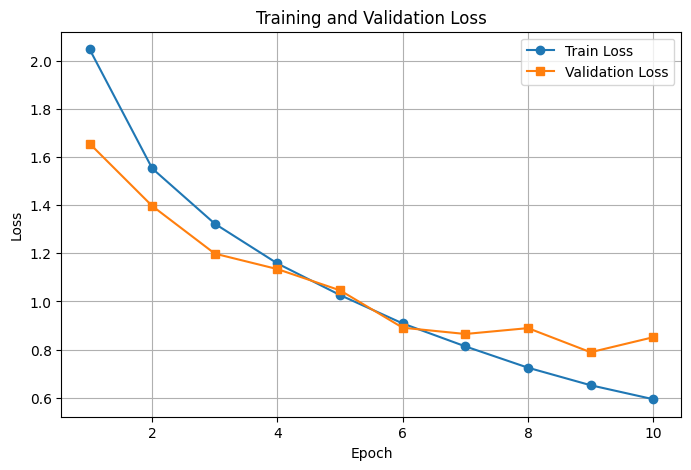

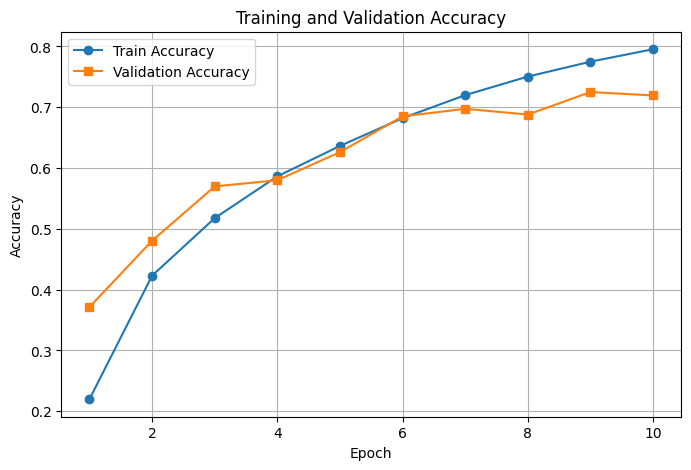

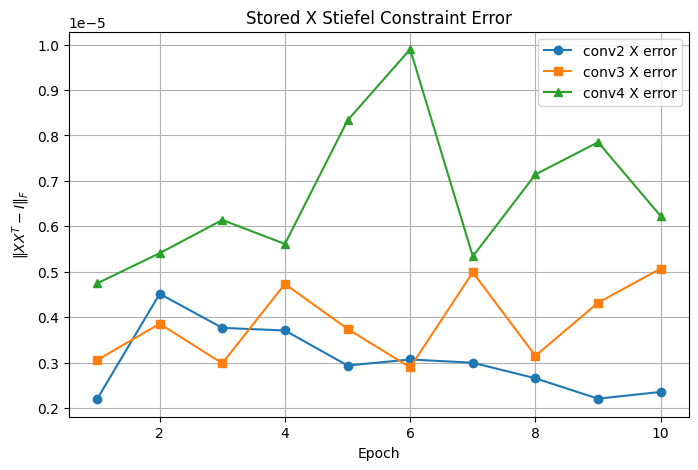

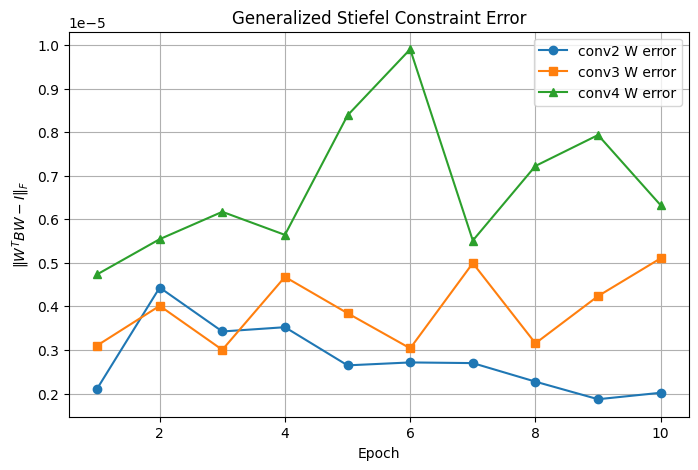

In [33]:
# ------------------------------------------------------------
# Plotting cell:
# show loss, accuracy, and manifold constraint errors
# ------------------------------------------------------------

import matplotlib.pyplot as plt

# make all series use a common length
L = min(
    len(train_losses),
    len(val_losses),
    len(train_accuracies),
    len(val_accuracies),
    len(stiefel_err_conv2),
    len(stiefel_err_conv3),
    len(stiefel_err_conv4),
    len(gstiefel_err_conv2),
    len(gstiefel_err_conv3),
    len(gstiefel_err_conv4),
)

epochs = range(1, L + 1)

# ------------------------------------------------------------
# plot training and validation loss
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses[:L], marker='o', label='Train Loss')
plt.plot(epochs, val_losses[:L], marker='s', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# plot training and validation accuracy
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_accuracies[:L], marker='o', label='Train Accuracy')
plt.plot(epochs, val_accuracies[:L], marker='s', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# plot standard Stiefel errors for the X variables
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(epochs, stiefel_err_conv2[:L], marker='o', label='conv2 X error')
plt.plot(epochs, stiefel_err_conv3[:L], marker='s', label='conv3 X error')
plt.plot(epochs, stiefel_err_conv4[:L], marker='^', label='conv4 X error')
plt.xlabel('Epoch')
plt.ylabel(r'$\|X X^T - I\|_F$')
plt.title('Stored X Stiefel Constraint Error')
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# plot generalized Stiefel errors for the reconstructed weights
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(epochs, gstiefel_err_conv2[:L], marker='o', label='conv2 W error')
plt.plot(epochs, gstiefel_err_conv3[:L], marker='s', label='conv3 W error')
plt.plot(epochs, gstiefel_err_conv4[:L], marker='^', label='conv4 W error')
plt.xlabel('Epoch')
plt.ylabel(r'$\|W^T B W - I\|_F$')
plt.title('Generalized Stiefel Constraint Error')
plt.legend()
plt.grid(True)
plt.show()